In [9]:
import os, sys
import json
from pathlib import Path
from importlib import reload

import matplotlib.pyplot as plt
import base64
import io

import random
import pandas as pd
import numpy as np
import PIL

from transformers import AutoTokenizer

hugg_auth_token = os.environ.get("HUGGINGFACE_KEY")

WORK_DIR = Path.cwd().parent

sys.path.append(str(WORK_DIR))
sys.path.append(str(WORK_DIR / "src/misc"))
from src import (
    main,
    datasets,
    video_tools,
    ollama_manager,
    prompt_formatters as pf,
)
from src.STAR_utils.visualization_tools import qa_visualization as qaviz


In [ ]:
import src.misc.VCG_100_originale as vcg


In [3]:
STAR_SMALL = WORK_DIR / "data/datasets/STAR/STAR_annotations/STAR_val_small_1000.json"

RAW_VIDEO_DIR = Path(WORK_DIR / 'data/datasets/action-genome/Charades_v1_480/')
SAVE_VIDEO_DIR = Path(WORK_DIR / "experiments/video_dump")


In [4]:
star_small_df = None
with open(STAR_SMALL) as f:
    star_small_df = pd.read_json(f)

star_small_df = star_small_df.drop_duplicates(subset=['question_id'])
star_small_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048 entries, 0 to 1047
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   question_id       1048 non-null   object 
 1   question          1048 non-null   object 
 2   video_id          1048 non-null   object 
 3   start             1048 non-null   float64
 4   end               1048 non-null   float64
 5   answer            1048 non-null   object 
 6   question_program  1048 non-null   object 
 7   choices           1048 non-null   object 
 8   situations        1048 non-null   object 
dtypes: float64(2), object(7)
memory usage: 73.8+ KB


In [ ]:
import matplotlib.pyplot as plt
import math

def plot_frames(frames, cols=10, figsize=(15, 15), title=None):
    """
    Plot a list of PIL Image frames in a grid.

    Parameters:
    - frames (list): List of PIL.Image.Image objects.
    - cols (int): Number of columns in the grid. Defaults to 10.
    - figsize (tuple): Size of the overall figure. Defaults to (15, 15).
    - title (str): Optional title for the figure.
    """
    num_frames = len(frames)
    cols = min(cols, num_frames)
    rows = math.ceil(num_frames / cols)

    fig, axes = plt.subplots(rows, cols, figsize=figsize)
    axes = axes.flatten()

    for ax in axes[num_frames:]:
        ax.axis('off')

    for i, frame in enumerate(frames):
        axes[i].imshow(frame)
        axes[i].axis('off')

    if title:
        fig.suptitle(title, fontsize=16)

    plt.tight_layout()
    plt.show()

# Example usage:
# frames = load_frames_from_folder("path/to/frames")
# plot_frames(frames, cols=10, figsize=(20, 10), title="Video Frames Grid")

# Expose the function for use
plot_frames


<function __main__.plot_frames(frames, cols=10, figsize=(15, 15), title=None)>

=[DEBUG] :- Extracting 20 frames


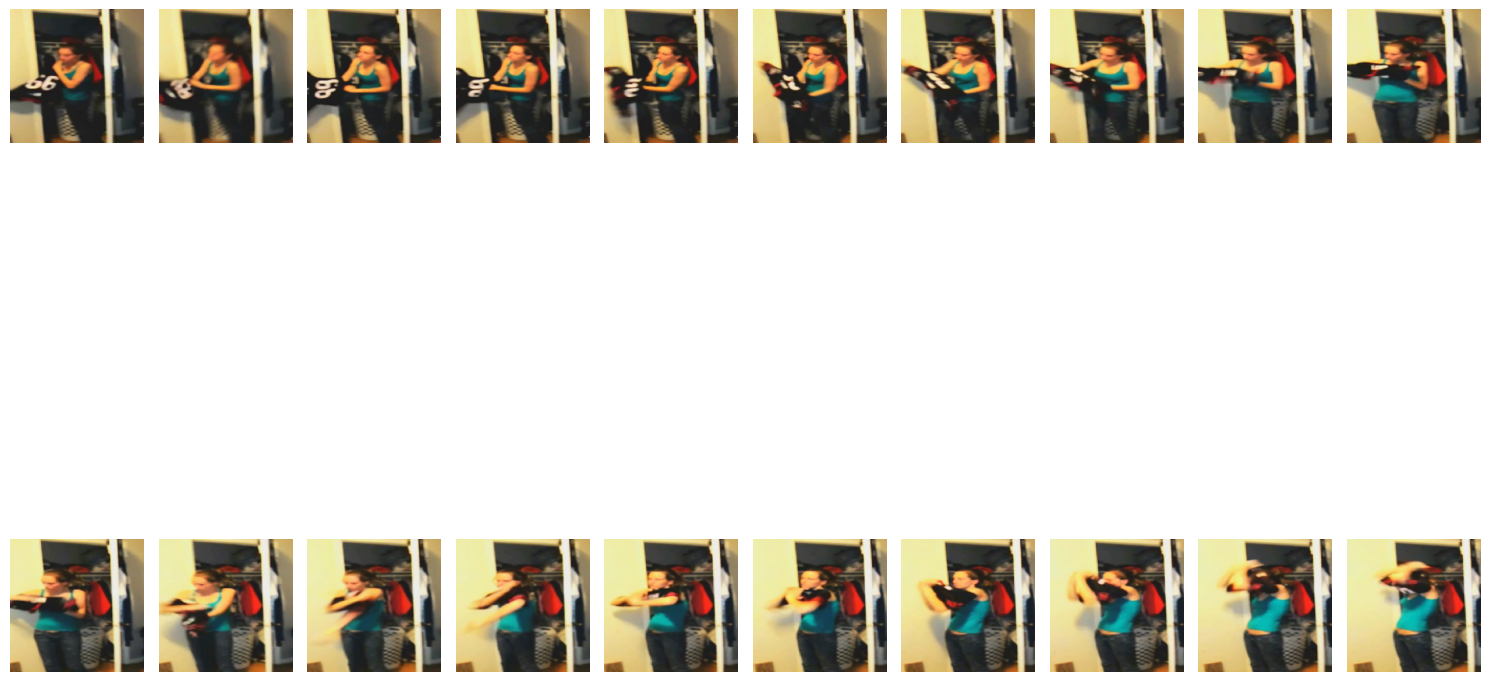

In [ ]:
sample = star_small_df.iloc[0]
dir, frame_paths = video_tools.extract_frames(Path(RAW_VIDEO_DIR, f"{sample['video_id']}.mp4"), start_time=sample.get('start', None), end_time=sample.get('end', None))
frames = vcg.load_frames_from_folder(dir)
plot_frames(frames)


In [7]:
fps = 1
sample = star_small_df.iloc[0]
b64_frames = video_tools.generate_video_frames(
    Path(RAW_VIDEO_DIR, f"{sample['video_id']}.mp4"),
    fps=fps,
    start=sample.get('start', None),
    end=sample.get('end', None),
)
b64_frames


=[INFO] :- Extracting frames from /home/lusha/star_code/data/datasets/action-genome/Charades_v1_480/ATV2F.mp4 with start: 0.0, end: 4.0, fps: 1, max_frames: None
=[DEBUG] :- Extracting 4 frames
=[DEBUG] :- Encoding frame frame_000001
=[DEBUG] :- Encoding frame frame_000002
=[DEBUG] :- Encoding frame frame_000003
=[DEBUG] :- Encoding frame frame_000004


[{'frame_id': {'frame_000001'},
  'encoding': '...'},
 {'frame_id': {'frame_000002'},
  'encoding': '...'},
 {'frame_id': {'frame_000003'},
  'encoding': '...'},
 {'frame_id': {'frame_000004'},
  'encoding': '...'}]

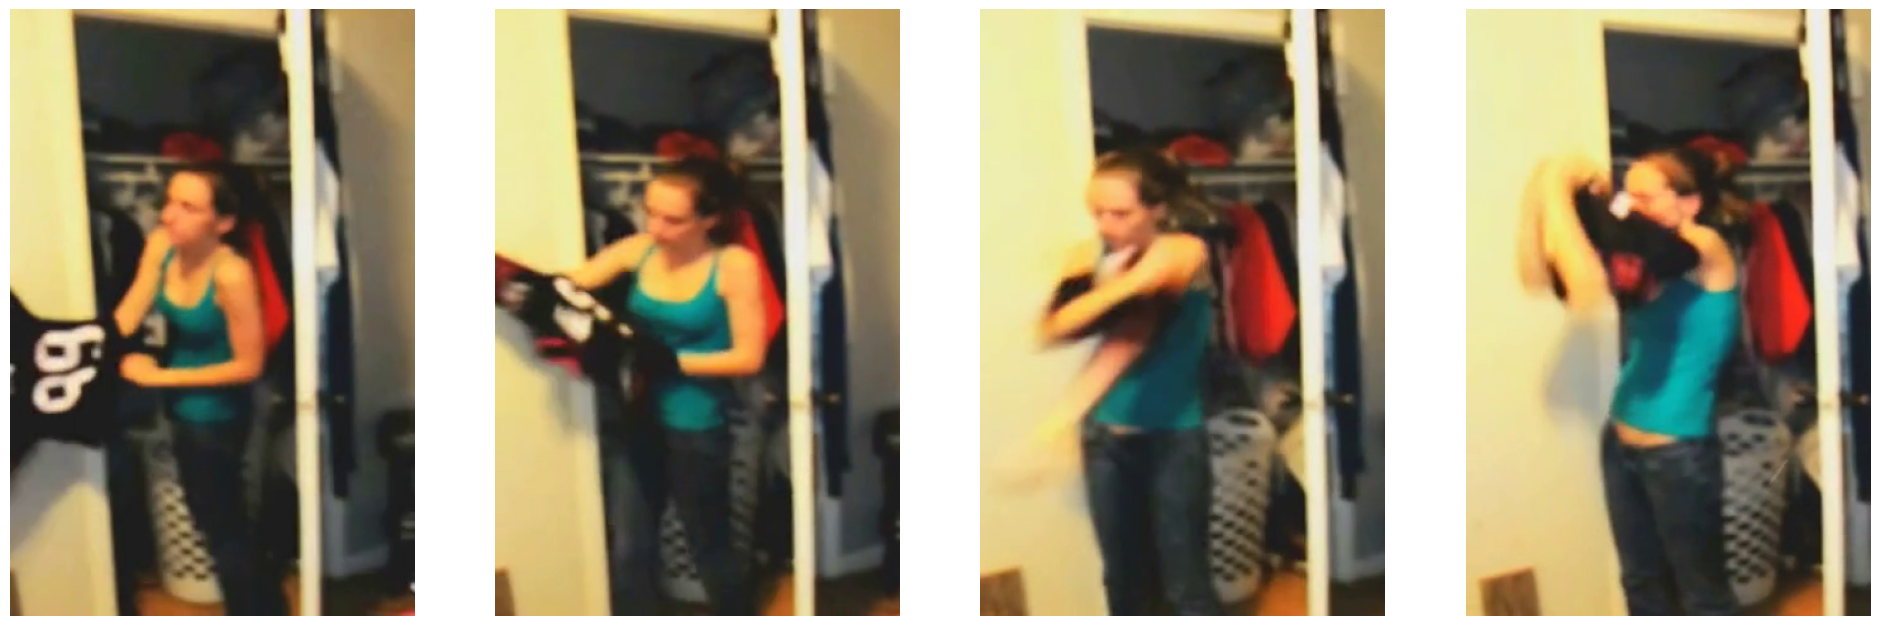

In [10]:
encodings = [frame['encoding'] for frame in b64_frames]

_, axs = plt.subplots(1, len(encodings), figsize=(24,8))

for img, ax in zip(encodings, axs):
    img = base64.b64decode(img)
    image = PIL.Image.open(io.BytesIO(img))
    image_np = np.array(image)  # Convert to NumPy array for Matplotlib
    ax.imshow(image_np)
    ax.axis('off')

plt.axis('off')  # Hide axes
plt.show()


In [11]:
# sys_file_path = WORK_DIR / "data/prompts/graph-gen/system_prompt.txt"
# sys_prompt = frames_tools._load_prompt_fromfile(sys_file_path)

model = "hf.co/unsloth/InternVL3-8B-Instruct-GGUF:Q4_K_M"
# model_options = _load_model_options()
ollama_params = {
    "model": model,
    "system": None,
    "stream": True,
    "options": {
        "num_ctx": 10240,
        "temperature": 0.1,
        "num_predict": 1024,
        "seed": 42,
    },
}

url = os.environ.get("OLLAMA_URL", "http://lusha_ollama:11435")
client = ollama_manager.OllamaRequestManager(url, ollama_params)


In [12]:
# pre-load the model
client.generate_completion("hello")


Hello! How can I assist you today?

Response at: 42.7 tk/s


{'content': 'Hello! How can I assist you today?', 'role': 'assistant'}

In [24]:
user_prompt = main._load_prompt_fromfile(WORK_DIR / "data/prompts/vqa/user_prompt_v2.txt")
follow_up = main._load_prompt_fromfile(WORK_DIR / "data/prompts/zero-shot-cot/auto_reply_ZS_CoT.txt")
pformatter = pf.MCQPromptWoutSTSG(user_prompt)
star_dataset = datasets.STARDataset(
    STAR_SMALL,
    pformatter
)



Dataset Statistics:
QA File: STAR_val_small_1000.json
Number of QA samples: 1048
QA sample keys: question_id, question, video_id, start, end, answer, question_program, choices, situations



In [ ]:
samples = [star_dataset[i] for i in range(3,7)]


In [28]:
print(samples[0]['prompt'])


You are an intelligent video comprehension model and are going to receive as input a sequence of images extracted from a video and a question. You need to analyze and describe the scene unfolding in the video (sequence of frames) following these guidelines:
1. Look for recurring objects;
2. Note that the same object may appear differently across frames due to low image quality, varying viewing angles, or partial obstructions. Carefully check objects with similar features (e.g. shape, color), appearing in different frames, as they may still be the same object;
3. Pay attention to how the person interacts with its environment
4. Understand the directional movement of the people and objects in the video
5. Carefully analyze the chronological sequence of the events occurring in the video;
6. Pay attention to the atomic and fine grained movement, pose and actions of the people in the video. Compose these atomic actions happening across the frame to infer the higher level action performed by

=[INFO] :- Extracting frames from /home/lusha/star_code/data/datasets/action-genome/Charades_v1_480/Z6HEA.mp4 with start: 0.0, end: 10.875, fps: 1, max_frames: None
=[DEBUG] :- Extracting 11 frames
=[DEBUG] :- Encoding frame frame_000001
=[DEBUG] :- Encoding frame frame_000002
=[DEBUG] :- Encoding frame frame_000003
=[DEBUG] :- Encoding frame frame_000004
=[DEBUG] :- Encoding frame frame_000005
=[DEBUG] :- Encoding frame frame_000006
=[DEBUG] :- Encoding frame frame_000007
=[DEBUG] :- Encoding frame frame_000008
=[DEBUG] :- Encoding frame frame_000009
=[DEBUG] :- Encoding frame frame_000010
=[DEBUG] :- Encoding frame frame_000011
=[INFO] :- Extracting frames from /home/lusha/star_code/data/datasets/action-genome/Charades_v1_480/FRLW2.mp4 with start: 3.4, end: 27.275, fps: 1, max_frames: None
=[DEBUG] :- Extracting 24 frames
=[DEBUG] :- Encoding frame frame_000001
=[DEBUG] :- Encoding frame frame_000002
=[DEBUG] :- Encoding frame frame_000003
=[DEBUG] :- Encoding frame frame_000004
=[DE

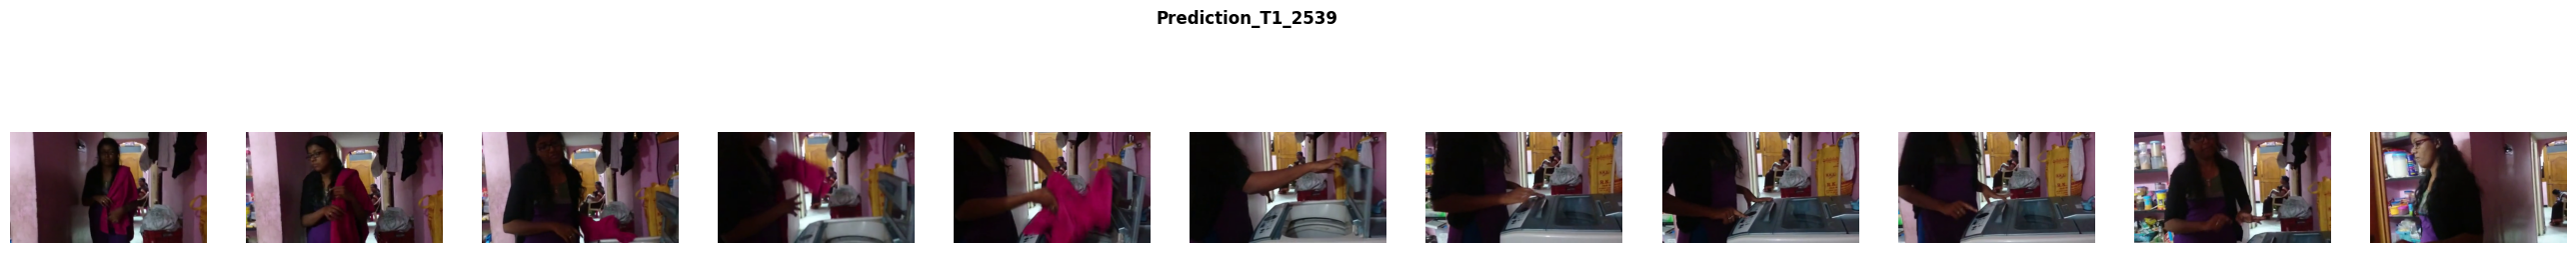

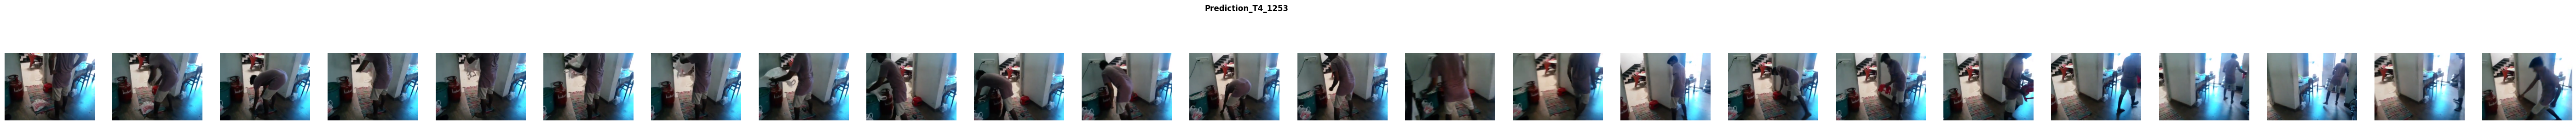

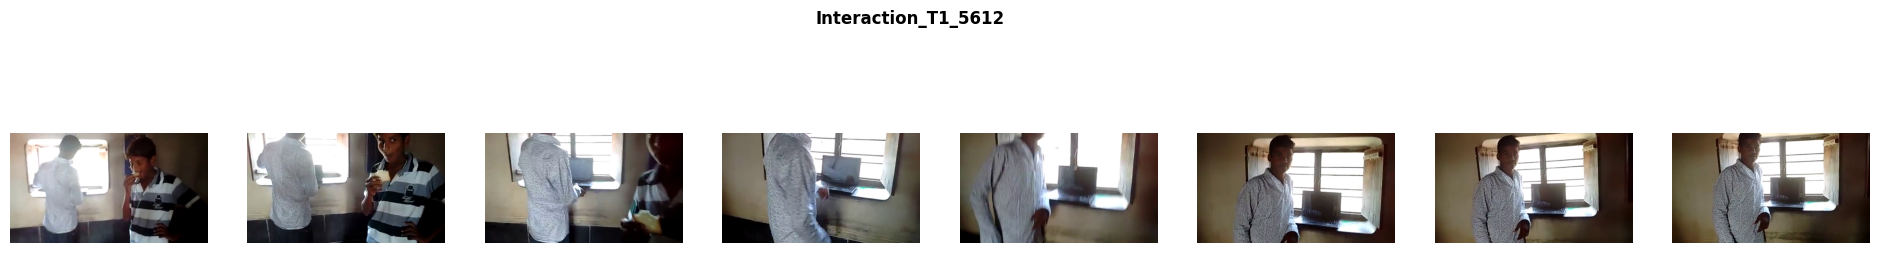

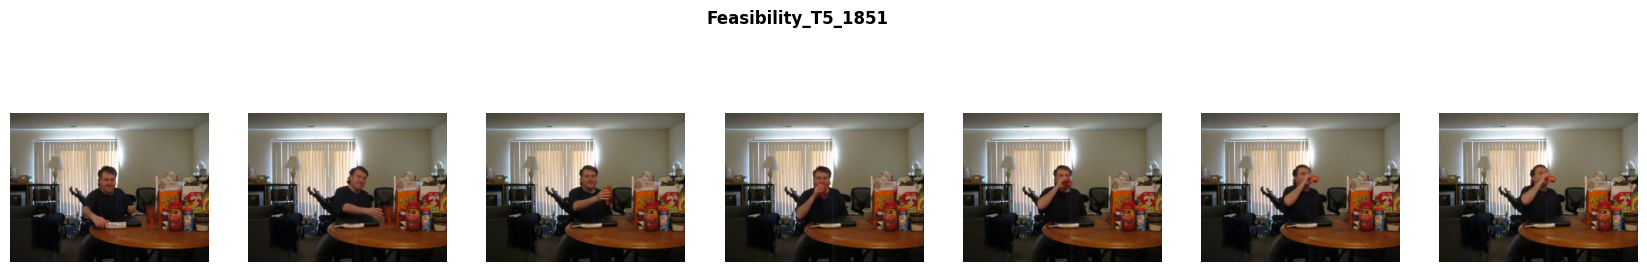

In [29]:
fps=1


for i, sample in enumerate(samples):
    question_id = sample['question_id']
    encodings = [
        frame['encoding'] for frame in video_tools.generate_video_frames(
            Path(RAW_VIDEO_DIR, f"{sample['video_id']}.mp4"),
            fps=fps,
            start=sample.get('start', None),
            end=sample.get('end', None),
        )
    ]

    fig, axs = plt.subplots(1, len(encodings), figsize=(3*len(encodings), 4))
    
    # Add title above the row
    fig.subplots_adjust(top=0.88)
    fig.suptitle(
        question_id,
        fontsize=12.0,
        fontweight='bold',
        y=0.94
    )
    
    for img, ax in zip(encodings, axs):
        img = base64.b64decode(img)
        image = PIL.Image.open(io.BytesIO(img))
        image_np = np.array(image)  # Convert to NumPy array for Matplotlib
        ax.imshow(image_np)
        ax.axis('off')

plt.axis('off')  # Hide axes
plt.show()


In [31]:
payload = main.img_payload(
    client.ollama_params,
    samples[2],
    RAW_VIDEO_DIR,
    fps,
    max_frames=None,
    batch_images=True
)


=[INFO] :- Extracting frames from /home/lusha/star_code/data/datasets/action-genome/Charades_v1_480/AS7SG.mp4 with start: 22.1, end: 31.0, fps: 1, max_frames: None
=[DEBUG] :- Extracting 8 frames
=[DEBUG] :- Encoding frame frame_000001
=[DEBUG] :- Encoding frame frame_000002
=[DEBUG] :- Encoding frame frame_000003
=[DEBUG] :- Encoding frame frame_000004
=[DEBUG] :- Encoding frame frame_000005
=[DEBUG] :- Encoding frame frame_000006
=[DEBUG] :- Encoding frame frame_000007
=[DEBUG] :- Encoding frame frame_000008
=[INFO] :- 
Video: AS7SG
=[INFO] :-  - interval: 22.1-31.0
=[INFO] :-  - 8 frames.
=[DEBUG] :- The prompt is:
You are an intelligent video comprehension model and are going to receive as input a sequence of images extracted from a video and a question. You need to analyze and describe the scene unfolding in the video (sequence of frames) following these guidelines:
1. Look for recurring objects;
2. Note that the same object may appear differently across frames due to low image qu

In [ ]:
print(payload[0]['payload']['messages'][0]['content'])


You are an intelligent video comprehension model and are going to receive as input a sequence of images extracted from a video and a question. You need to analyze and describe the scene unfolding in the video (sequence of frames) following these guidelines:
1. Look for recurring objects;
2. Note that the same object may appear differently across frames due to low image quality, varying viewing angles, or partial obstructions. Carefully check objects with similar features (e.g. shape, color), appearing in different frames, as they may still be the same object;
3. Pay attention to how the person interacts with its environment
4. Understand the directional movement of the people and objects in the video
5. Carefully analyze the chronological sequence of the events occurring in the video;
6. Pay attention to the atomic and fine grained movement, pose and actions of the people in the video. Compose these atomic actions happening across the frame to infer the higher level action performed by

In [34]:
if True:
    main.stream_sgg(
        ollama_client=client,
        dataset=[samples[2]],
        reply=follow_up,
        videos_dir=RAW_VIDEO_DIR,
        fps=fps,
        output_filepath=WORK_DIR / 'notebooks/sgg_qbias_test.jsonl',
        max_frames=None,
        batch_images=True
    
        
    )


=[WARNING] :- File /home/lusha/star_code/notebooks/sgg_qbias_test.jsonl already exists!
=[INFO] :- Responses will be saved to: /home/lusha/star_code/notebooks/sgg_qbias_test_copy7.jsonl
=[INFO] :- Errors will be logged to: outputs/errors_20250715_10:00:31.txt
=[INFO] :- ===== Starting Response Generation =====
=[INFO] :- Extracting frames from /home/lusha/star_code/data/datasets/action-genome/Charades_v1_480/AS7SG.mp4 with start: 22.1, end: 31.0, fps: 1, max_frames: None
=[DEBUG] :- Extracting 8 frames
=[DEBUG] :- Encoding frame frame_000001
=[DEBUG] :- Encoding frame frame_000002
=[DEBUG] :- Encoding frame frame_000003
=[DEBUG] :- Encoding frame frame_000004
=[DEBUG] :- Encoding frame frame_000005
=[DEBUG] :- Encoding frame frame_000006
=[DEBUG] :- Encoding frame frame_000007
=[DEBUG] :- Encoding frame frame_000008
=[INFO] :- 
Video: AS7SG
=[INFO] :-  - interval: 22.1-31.0
=[INFO] :-  - 8 frames.
=[DEBUG] :- The prompt is:
You are an intelligent video comprehension model and are going

### Question Interpretation
The question asks which object was opened by the person in the video. The alternatives provided are: A. The box, B. The window, C. The door, D. The laptop, E. None of the others.

### Video Analysis
1. **Image 0**: Two individuals are present near a window; one is interacting with something on the windowsill.
2. **Image 1**: The same scene as Image 0 but slightly different angles and lighting.
3. **Image 2**: A person in a striped shirt appears to be moving towards or away from the window, holding an object (possibly food).
4. **Image 3**: The individual near the window is now interacting with what looks like a laptop placed on the windowsill.
5. **Images 4-7**: The focus remains on the individual by the window who continues to interact with the laptop.

### Alternative Evaluation
A. **The box** - There are no visible boxes in any of the images, so this option is unlikely.
B. **The window** - While there is a window present, it does not appear that anyone op

=[INFO] :- Removing image entry




Response at: 26.8 tk/s


In [302]:
SGG_QBIAS_PATH = WORK_DIR / "outputs/sgg/sggm_qbias_alt1_gemma3:4b-it-qat_20250707_21:59:00.jsonl"
sgg_qbias = pd.read_json(SGG_QBIAS_PATH, lines=True)
sgg_qbias.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1039 entries, 0 to 1038
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   question_id   1039 non-null   object
 1   chat_history  1039 non-null   object
 2   stsg          1039 non-null   object
dtypes: object(3)
memory usage: 24.5+ KB


In [303]:
sgg_qbias.head()


,question_id,chat_history,stsg
0,Feasibility_T5_102,"[{'role': 'user', 'content': 'You are an intel...",Here’s the spatio-temporal scene graph based o...
1,Feasibility_T2_860,"[{'role': 'user', 'content': 'You are an intel...",Here’s a spatio-temporal scene graph represent...
2,Feasibility_T2_556,"[{'role': 'user', 'content': 'You are an intel...","Okay, here’s a spatio-temporal scene graph rep..."
3,Prediction_T1_2539,"[{'role': 'user', 'content': 'You are an intel...",Here’s a spatio-temporal scene graph represent...
4,Prediction_T4_1253,"[{'role': 'user', 'content': 'You are an intel...",Here’s a spatio-temporal scene graph represent...


In [121]:
mss = []
j = 0
for i in range(star_small_df.shape[0]):
    vid = star_small_df.iloc[i]['video_id']
    qid = sgg_qbias.iloc[j]['qid']
    
    if qid != vid:
        print(f"Mismatch at {i}: qid={qid!r} vs video_id={vid!r}")
        mss.append(i)
        continue
    j += 1
    

Mismatch at 105: qid='Z97SD' vs video_id='MA15X'
Mismatch at 315: qid='M1TZR' vs video_id='MA15X'
Mismatch at 330: qid='HL5OP' vs video_id='MA15X'
Mismatch at 616: qid='EO6OI' vs video_id='STAFD'
Mismatch at 746: qid='GTK8W' vs video_id='MA15X'
Mismatch at 748: qid='L7HA6' vs video_id='MA15X'
Mismatch at 831: qid='FTG07' vs video_id='AFTMI'
Mismatch at 843: qid='320ZB' vs video_id='GPR89'
Mismatch at 932: qid='DR7K0' vs video_id='MA15X'
